In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
mat_path = "../student/student-mat.csv"
por_path = "../student/student-por.csv"

df_mat = pd.read_csv(mat_path, sep=";")
df_mat["subject"] = "mat"
df_por = pd.read_csv(por_path, sep=";")
df_por["subject"] = "por"
df = pd.concat([df_mat, df_por], axis=0, ignore_index=True)

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


In [4]:
df.shape

(1044, 34)

In [5]:
print("Missing values:")
missing = df.isna().sum()
missing

Missing values:


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
subject       0
dtype: int64

In [6]:
print("Basic stats (numeric):")
display(df.describe())

Basic stats (numeric):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


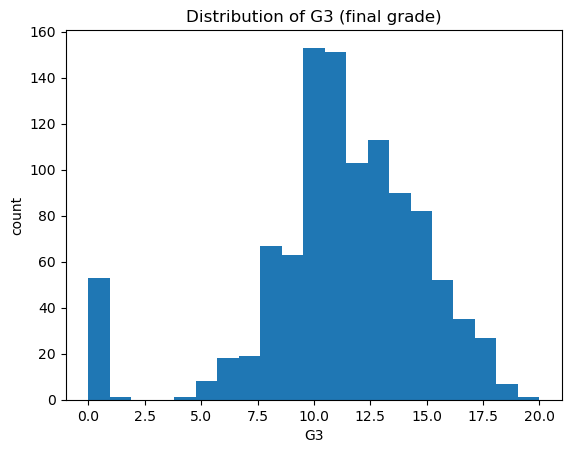

In [7]:
plt.figure()
plt.hist(df["G3"], bins=21)
plt.title("Distribution of G3 (final grade)")
plt.xlabel("G3")
plt.ylabel("count")
plt.show()

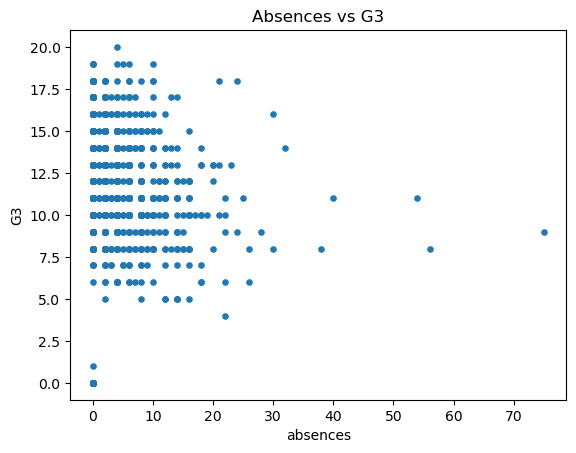

In [8]:
plt.figure()
plt.scatter(df["absences"], df["G3"], s=14)
plt.title("Absences vs G3")
plt.xlabel("absences")
plt.ylabel("G3")
plt.show()

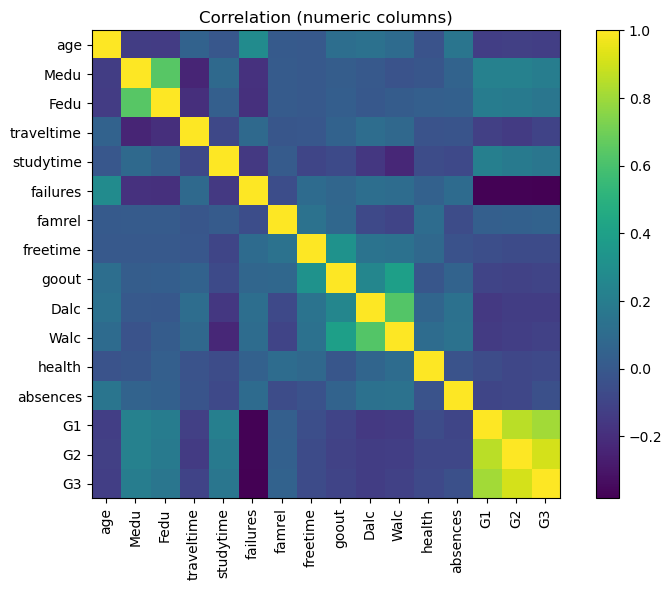

In [9]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols_all].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr.values)
plt.title("Correlation (numeric columns)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

In [10]:
print("Correlation with G3 (numeric only):")
display(corr["G3"].sort_values(ascending=False))

Correlation with G3 (numeric only):


G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64

In [11]:
DROP_COLS = ["G1", "G2"]
df_model = df.drop(columns=DROP_COLS).copy()
df_model = df_model.drop_duplicates().reset_index(drop=True)
print("After dropping G1/G2 and exact duplicates:", df_model.shape)

After dropping G1/G2 and exact duplicates: (1044, 32)


In [12]:
cat_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

In [13]:
X = df_model[cat_cols + num_cols].copy()

# Preprocessing:
# - numeric: standardize
# - categorical: one-hot encode
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

In [14]:
X_train, X_test = train_test_split(
    X, test_size=0.30, random_state=RANDOM_STATE
)

In [15]:
base_contamination = 0.08

pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("iforest", IsolationForest(
            n_estimators=200,
            contamination=base_contamination,
            max_samples="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]
)

pipe.fit(X_train)

,steps,"[('prep', ...), ('iforest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
pred_train_raw = pipe.predict(X_train)
pred_test_raw = pipe.predict(X_test)

train_outlier = (pred_train_raw == -1).astype(int)
test_outlier = (pred_test_raw == -1).astype(int)

In [17]:
print("Predicted outlier rate (train):", train_outlier.mean())
print("Predicted outlier rate (test): ", test_outlier.mean())

Predicted outlier rate (train): 0.08082191780821918
Predicted outlier rate (test):  0.09872611464968153


In [18]:
# decision_function: higher = more normal; invert to get "outlier score"
train_outlier_score = -pipe.decision_function(X_train)
test_outlier_score = -pipe.decision_function(X_test)

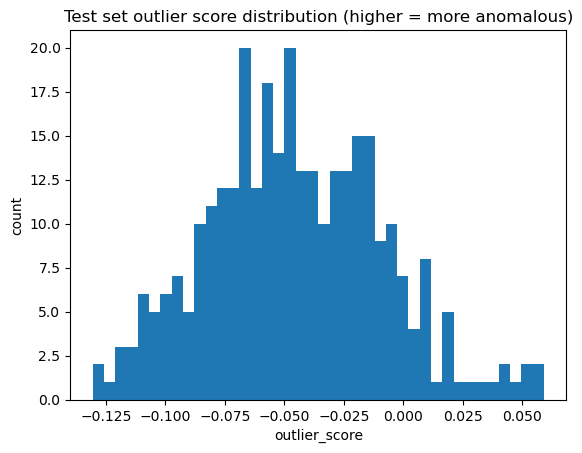

In [19]:
plt.figure()
plt.hist(test_outlier_score, bins=40)
plt.title("Test set outlier score distribution (higher = more anomalous)")
plt.xlabel("outlier_score")
plt.ylabel("count")
plt.show()

In [20]:
# Interpretation
k = 10
test_idx = np.argsort(test_outlier_score)[-k:][::-1]
top_outliers = X_test.iloc[test_idx].copy()
top_outliers["outlier_score"] = test_outlier_score[test_idx]
top_outliers["pred_outlier"] = test_outlier[test_idx]

print("Top predicted outliers (test):")
display(top_outliers.T)

Top predicted outliers (test):


,882,247,336,829,371,800,808,310,361,370
school,MS,GP,GP,MS,MS,GP,GP,GP,MS,MS
sex,F,M,F,F,M,F,M,F,M,F
address,R,U,R,U,R,U,R,U,R,U
famsize,LE3,GT3,GT3,LE3,LE3,LE3,LE3,LE3,LE3,LE3
Pstatus,A,T,A,A,T,A,T,T,T,T
Mjob,other,services,services,at_home,at_home,at_home,at_home,services,at_home,services
Fjob,other,services,at_home,other,services,other,other,services,other,services
reason,course,other,home,reputation,other,home,course,home,other,home
guardian,other,mother,other,mother,father,other,other,other,mother,other
schoolsup,no,no,no,no,no,no,no,no,no,no


In [21]:
test_with_flags = X_test.copy()
test_with_flags["pred_outlier"] = test_outlier
for col in [c for c in num_cols if c in test_with_flags.columns]:
    grp = test_with_flags.groupby("pred_outlier")[col].agg(["mean", "median"])
    print(f"\nNumeric feature summary by predicted outlier flag: {col}")
    display(grp)


Numeric feature summary by predicted outlier flag: age


,mean,median
pred_outlier,,
0,16.611307,16.0
1,18.161290,18.0



Numeric feature summary by predicted outlier flag: Medu


,mean,median
pred_outlier,,
0,2.558304,3.0
1,1.935484,2.0



Numeric feature summary by predicted outlier flag: Fedu


,mean,median
pred_outlier,,
0,2.325088,2.0
1,1.870968,2.0



Numeric feature summary by predicted outlier flag: traveltime


,mean,median
pred_outlier,,
0,1.512367,1.0
1,1.741935,2.0



Numeric feature summary by predicted outlier flag: studytime


,mean,median
pred_outlier,,
0,2.060071,2.0
1,1.838710,2.0



Numeric feature summary by predicted outlier flag: failures


,mean,median
pred_outlier,,
0,0.229682,0.0
1,1.064516,1.0



Numeric feature summary by predicted outlier flag: famrel


,mean,median
pred_outlier,,
0,3.893993,4.0
1,3.806452,4.0



Numeric feature summary by predicted outlier flag: freetime


,mean,median
pred_outlier,,
0,3.212014,3.0
1,3.225806,3.0



Numeric feature summary by predicted outlier flag: goout


,mean,median
pred_outlier,,
0,3.120141,3.0
1,3.161290,3.0



Numeric feature summary by predicted outlier flag: Dalc


,mean,median
pred_outlier,,
0,1.427562,1.0
1,2.000000,1.0



Numeric feature summary by predicted outlier flag: Walc


,mean,median
pred_outlier,,
0,2.173145,2.0
1,2.483871,2.0



Numeric feature summary by predicted outlier flag: health


,mean,median
pred_outlier,,
0,3.579505,4.0
1,3.322581,3.0



Numeric feature summary by predicted outlier flag: absences


,mean,median
pred_outlier,,
0,4.106007,2.0
1,8.000000,6.0



Numeric feature summary by predicted outlier flag: G3


,mean,median
pred_outlier,,
0,11.371025,11.0
1,10.129032,10.0


In [22]:
df_test = X_test.copy()
df_test["outlier"] = test_outlier
df_test["outlier_score"] = test_outlier_score

normal = df_test[df_test["outlier"] == 0]
anomalies = df_test[df_test["outlier"] == 1]

normal_mean = normal[num_cols].mean()
anomaly_mean = anomalies[num_cols].mean()

feature_contribution = anomaly_mean - normal_mean

contribution_df = pd.DataFrame({
    "normal_mean": normal_mean,
    "anomaly_mean": anomaly_mean,
    "difference": feature_contribution
})

contribution_df = contribution_df.reindex(contribution_df["difference"].abs().sort_values(ascending=False).index)

display(contribution_df)

,normal_mean,anomaly_mean,difference
absences,4.106007,8.000000,3.893993
age,16.611307,18.161290,1.549983
G3,11.371025,10.129032,-1.241992
failures,0.229682,1.064516,0.834834
Medu,2.558304,1.935484,-0.622820
Dalc,1.427562,2.000000,0.572438
Fedu,2.325088,1.870968,-0.454121
Walc,2.173145,2.483871,0.310726
health,3.579505,3.322581,-0.256925
traveltime,1.512367,1.741935,0.229568


In [23]:
# Sensitivity Analysis
def fit_iforest_get_outputs(
    X_train, X_test, preprocess,
    contamination=0.08, n_estimators=200, max_samples="auto",
    random_state=42
):
    pipe = Pipeline(
        steps=[
            ("prep", preprocess),
            ("iforest", IsolationForest(
                n_estimators=n_estimators,
                contamination=contamination,
                max_samples=max_samples,
                random_state=random_state,
                n_jobs=-1
            ))
        ]
    )
    pipe.fit(X_train)
    outlier_score = -pipe.decision_function(X_test)
    pred_outlier = (pipe.predict(X_test) == -1).astype(int)

    return pipe, outlier_score, pred_outlier

def topk_overlap(score_a, score_b, k=50):
    """Overlap fraction of the top-k highest outlier scores."""
    idx_a = set(np.argsort(score_a)[-k:])
    idx_b = set(np.argsort(score_b)[-k:])
    return len(idx_a & idx_b) / k

In [24]:
BASE_CONTAM = base_contamination  # e.g., 0.08
BASE_TREES = 200
BASE_MAXS = "auto"
TOPK = 50

_, base_score, base_pred = fit_iforest_get_outputs(
    X_train, X_test, preprocess,
    contamination=BASE_CONTAM,
    n_estimators=BASE_TREES,
    max_samples=BASE_MAXS,
    random_state=RANDOM_STATE
)

print("Base predicted outlier rate:", float(base_pred.mean()))

Base predicted outlier rate: 0.09872611464968153


Sensitivity: contamination


,contamination,n_estimators,max_samples,pred_outlier_rate,top50_overlap_vs_base,score_mean,score_std
0,0.03,200,auto,0.050955,1.0,-0.061775,0.036722
1,0.05,200,auto,0.079618,1.0,-0.052483,0.036722
2,0.08,200,auto,0.098726,1.0,-0.045489,0.036722
3,0.10,200,auto,0.133758,1.0,-0.041564,0.036722
4,0.12,200,auto,0.162420,1.0,-0.036893,0.036722


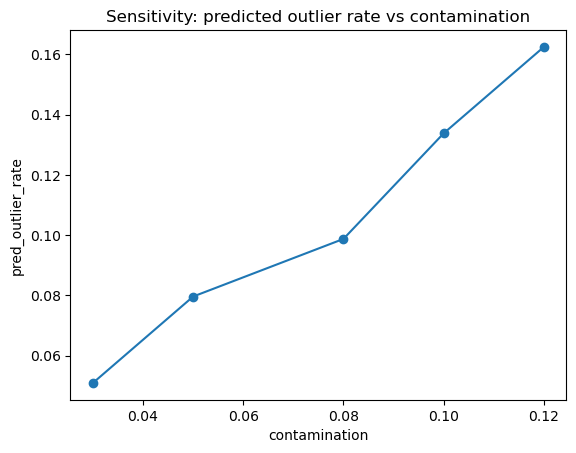

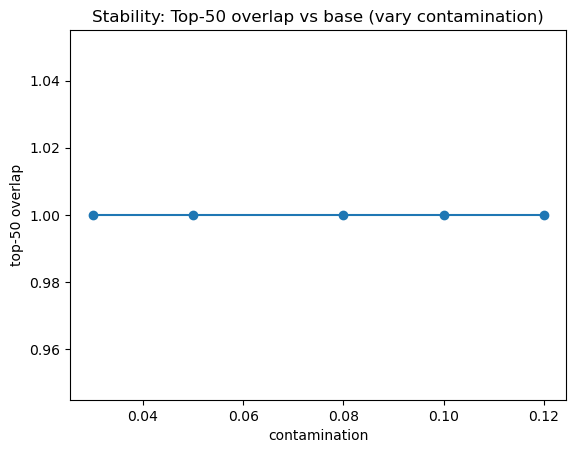

In [26]:
# Contamination
contamination_grid = [0.03, 0.05, 0.08, 0.10, 0.12]

rows = []
for c in contamination_grid:
    _, score, pred = fit_iforest_get_outputs(
        X_train, X_test, preprocess,
        contamination=c,
        n_estimators=BASE_TREES,
        max_samples=BASE_MAXS,
        random_state=RANDOM_STATE
    )
    rows.append({
        "contamination": c,
        "n_estimators": BASE_TREES,
        "max_samples": BASE_MAXS,
        "pred_outlier_rate": float(pred.mean()),
        "top{}_overlap_vs_base".format(TOPK): topk_overlap(base_score, score, k=TOPK),
        "score_mean": float(np.mean(score)),
        "score_std": float(np.std(score)),
    })

sens_contam_df = pd.DataFrame(rows).sort_values("contamination")
print("Sensitivity: contamination")
display(sens_contam_df)

plt.figure()
plt.plot(sens_contam_df["contamination"], sens_contam_df["pred_outlier_rate"], marker="o")
plt.title("Sensitivity: predicted outlier rate vs contamination")
plt.xlabel("contamination")
plt.ylabel("pred_outlier_rate")
plt.show()

plt.figure()
plt.plot(sens_contam_df["contamination"], sens_contam_df["top{}_overlap_vs_base".format(TOPK)], marker="o")
plt.title(f"Stability: Top-{TOPK} overlap vs base (vary contamination)")
plt.xlabel("contamination")
plt.ylabel(f"top-{TOPK} overlap")
plt.show()

As the contamination parameter increases, the model flags more students as outliers. However, the overlap of the top 50 anomaly scores remains 1.0 across all settings, meaning the same students are consistently identified as the most abnormal. This suggests the anomaly detection results are stable and not highly sensitive to the contamination parameter.


Sensitivity: n_estimators


,contamination,n_estimators,max_samples,pred_outlier_rate,top50_overlap_vs_base,score_mean,score_std
0,0.08,50,auto,0.117834,0.82,-0.051131,0.041279
1,0.08,100,auto,0.101911,0.86,-0.046323,0.037936
2,0.08,200,auto,0.098726,1.00,-0.045489,0.036722
3,0.08,300,auto,0.111465,0.90,-0.044973,0.036398
4,0.08,500,auto,0.114650,0.92,-0.045490,0.036411


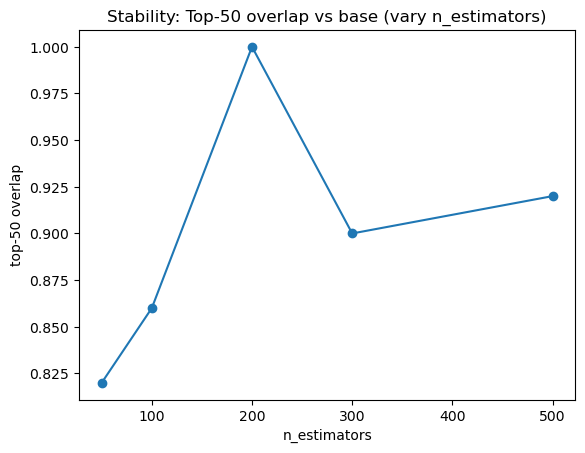

In [27]:
# N_estimators
n_estimators_grid = [50, 100, 200, 300, 500]

rows = []
for n in n_estimators_grid:
    _, score, pred = fit_iforest_get_outputs(
        X_train, X_test, preprocess,
        contamination=BASE_CONTAM,
        n_estimators=n,
        max_samples=BASE_MAXS,
        random_state=RANDOM_STATE
    )
    rows.append({
        "contamination": BASE_CONTAM,
        "n_estimators": n,
        "max_samples": BASE_MAXS,
        "pred_outlier_rate": float(pred.mean()),
        "top{}_overlap_vs_base".format(TOPK): topk_overlap(base_score, score, k=TOPK),
        "score_mean": float(np.mean(score)),
        "score_std": float(np.std(score)),
    })

sens_trees_df = pd.DataFrame(rows).sort_values("n_estimators")
print("\nSensitivity: n_estimators")
display(sens_trees_df)

plt.figure()
plt.plot(sens_trees_df["n_estimators"], sens_trees_df["top{}_overlap_vs_base".format(TOPK)], marker="o")
plt.title(f"Stability: Top-{TOPK} overlap vs base (vary n_estimators)")
plt.xlabel("n_estimators")
plt.ylabel(f"top-{TOPK} overlap")
plt.show()

The sensitivity analysis shows that the anomaly detection results become more stable as the number of trees increases. With only 50 trees, the overlap with the base model is about 0.82, indicating some variation in detected anomalies.


Sensitivity: max_samples


,contamination,n_estimators,max_samples,pred_outlier_rate,top50_overlap_vs_base,score_mean,score_std
0,0.08,200,0.3,0.101911,0.88,-0.049357,0.038143
1,0.08,200,0.6,0.121019,0.82,-0.045919,0.037922
2,0.08,200,1.0,0.133758,0.86,-0.044426,0.039318
3,0.08,200,auto,0.098726,1.00,-0.045489,0.036722


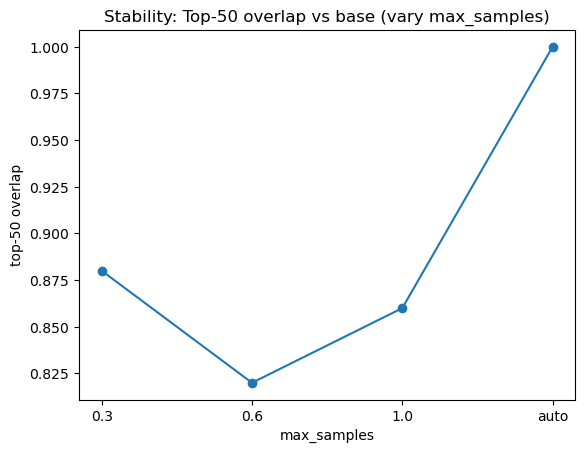

In [28]:
max_samples_grid = [0.3, 0.6, 1.0, "auto"]

rows = []
for ms in max_samples_grid:
    _, score, pred = fit_iforest_get_outputs(
        X_train, X_test, preprocess,
        contamination=BASE_CONTAM,
        n_estimators=BASE_TREES,
        max_samples=ms,
        random_state=RANDOM_STATE
    )
    rows.append({
        "contamination": BASE_CONTAM,
        "n_estimators": BASE_TREES,
        "max_samples": ms,
        "pred_outlier_rate": float(pred.mean()),
        "top{}_overlap_vs_base".format(TOPK): topk_overlap(base_score, score, k=TOPK),
        "score_mean": float(np.mean(score)),
        "score_std": float(np.std(score)),
    })

sens_samples_df = pd.DataFrame(rows)
print("\nSensitivity: max_samples")
display(sens_samples_df)

plt.figure()
plt.plot(sens_samples_df["max_samples"].astype(str), sens_samples_df["top{}_overlap_vs_base".format(TOPK)], marker="o")
plt.title(f"Stability: Top-{TOPK} overlap vs base (vary max_samples)")
plt.xlabel("max_samples")
plt.ylabel(f"top-{TOPK} overlap")
plt.show()

Changing max_samples slightly affects the results. As it increases from 0.3 to 1.0, the predicted outlier rate rises from about 10% to 13%, meaning more students are flagged as anomalies. The top-50 overlap stays between 0.82 and 0.88, showing most detected anomalies remain similar.